In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

In [2]:
import yfinance as yf

In [3]:
pair1_y = 'KO'
pair1_x = 'PEP'
pair2_y = 'XOM'
pair2_x = 'CVX'

BASE_DIR = "C:/Users/Serena/OneDrive - University of Illinois - Urbana/Desktop/Columbia/5291/Project"
DATA_DIR = BASE_DIR + "/Data"
INPUT_DIR = DATA_DIR + "/yfinance_data"
LOG_DIR = DATA_DIR + "/log_price_log_return"

KO_PEP  = pd.read_csv(INPUT_DIR + "/KO_PEP.csv")
# PEP = pd.read_csv(DATA_DIR + "/PEP_clean.csv")
XOM_CVX = pd.read_csv(INPUT_DIR + "/XOM_CVX.csv")
# CVX = pd.read_csv(DATA_DIR + "/CVX_clean.csv")
# Censor missing data
print(XOM_CVX.isna().sum())

# print(f"Shape of data set: {data.shape}")
# print(f"Range of date: {data.index[0]} to {data.index[-1]}")
# print(data.head())

Date    0
XOM     0
CVX     0
dtype: int64


# log price and log yield

In [4]:
# def log_return(prices):
#     log_prices = np.log(prices)
#     log_returns = log_prices.diff().dropna()
#     return log_returns

KO_log_prices = pd.read_csv(LOG_DIR + "/KO_log_prices.csv")
PEP_log_prices = pd.read_csv(LOG_DIR + "/PEP_log_prices.csv")
XOM_log_prices = pd.read_csv(LOG_DIR + "/XOM_log_prices.csv")
CVX_log_prices = pd.read_csv(LOG_DIR + "/CVX_log_prices.csv")

KO_log_returns = pd.read_csv(LOG_DIR + "/KO_log_returns.csv")
PEP_log_returns = pd.read_csv(LOG_DIR + "/PEP_log_returns.csv")
XOM_log_returns = pd.read_csv(LOG_DIR + "/XOM_log_returns.csv")
CVX_log_returns = pd.read_csv(LOG_DIR + "/CVX_log_returns.csv")

KO_log_prices.head()
# print(KO_log_returns.isna())


,Date,KO
0,2010-01-04,2.851650
1,2010-01-05,2.839480
2,2010-01-06,2.839124
3,2010-01-07,2.836636
4,2010-01-08,2.817954


# OLS_spread and OLS_z (static)

In [5]:
KO_log_prices = KO_log_prices.set_index("Date")
PEP_log_prices = PEP_log_prices.set_index("Date")

In [6]:
XOM_log_prices = XOM_log_prices.set_index("Date")
CVX_log_prices = CVX_log_prices.set_index("Date")   

In [7]:
'''
static OLS regression to get static spread and rolling z-score
1 rolling windows: rolling z-score normalization window


y = alpha + beta * x
spread_t = y_t - (alpha_t + beta_t * x_t)

that is, 2012-01-03 的 spread
= 当天实际 y - 当天预测值
z-score_t = (spread_t - mean(spread_{t-252:t-1})) / std(spread_{t-252:t-1})
再用过去252天 spread 算 rolling mean/std
'''
def calculate_ols_spread_and_zscore(y, x, lookback=252):
    # spread = pd.Series(index=y.index, dtype=float)
    # beta = pd.Series(index=y.index, dtype=float)
    # alpha = pd.Series(index=y.index, dtype=float)
    X = np.column_stack([np.ones(len(x)), x.values])
    Y = y.values

    coeffs = np.linalg.lstsq(X, Y, rcond=None)[0]
    alpha = coeffs[0]
    beta = coeffs[1]

    # static spread
    spread = y - (alpha + beta * x)

    # compute rolling z-score
    rolling_mean = spread.shift(1).rolling(window = lookback).mean()
    rolling_std = spread.shift(1).rolling(window = lookback).std()

    zscore = (spread - rolling_mean) / rolling_std

    return spread, zscore, beta, alpha

spread_ols_ko_pep, zscore_ols_ko_pep, beta_ols_ko_pep, alpha_ols_ko_pep = calculate_ols_spread_and_zscore(
    KO_log_prices['KO'], PEP_log_prices['PEP']
)

spread_ols_xom_cvx, zscore_ols_xom_cvx, beta_ols_xom_cvx, alpha_ols_xom_cvx = calculate_ols_spread_and_zscore(
    XOM_log_prices['XOM'], CVX_log_prices['CVX']
)


In [8]:
beta_ols_ko_pep

np.float64(0.7943230953448571)

In [9]:
def build_partial_backtest_input(pair_name, log_price_y, log_price_x, ols_spread, ols_zscore, ols_beta, ols_alpha):
    y_col, x_col = pair_name.split("-")

    df = pd.DataFrame(index=log_price_y.index)

    df["Date"] = df.index
    df["pair"] = pair_name

    df["return_y"] = log_price_y[y_col].diff()
    df["return_x"] = log_price_x[x_col].diff()

    df["OLS_spread"] = ols_spread
    df["OLS_zscore"] = ols_zscore
    df["OLS_beta"] = ols_beta
    df["OLS_alpha"] = ols_alpha

    return df.reset_index(drop=True)

ko_pep_backtest_input = build_partial_backtest_input(
    "KO-PEP", KO_log_prices, PEP_log_prices, spread_ols_ko_pep, zscore_ols_ko_pep, beta_ols_ko_pep, alpha_ols_ko_pep)
xom_cvx_backtest_input = build_partial_backtest_input(
    "XOM-CVX", XOM_log_prices, CVX_log_prices, spread_ols_xom_cvx, zscore_ols_xom_cvx, beta_ols_xom_cvx, alpha_ols_xom_cvx)

In [10]:
ko_pep_backtest_input.head()

,Date,pair,return_y,return_x,OLS_spread,OLS_zscore,OLS_beta,OLS_alpha
0,2010-01-04,KO-PEP,NaN,NaN,-0.073419,NaN,0.794323,0.043497
1,2010-01-05,KO-PEP,-0.012170,0.012011,-0.095130,NaN,0.794323,0.043497
2,2010-01-06,KO-PEP,-0.000355,-0.010053,-0.087500,NaN,0.794323,0.043497
3,2010-01-07,KO-PEP,-0.002488,-0.006376,-0.084923,NaN,0.794323,0.043497
4,2010-01-08,KO-PEP,-0.018682,-0.003286,-0.100995,NaN,0.794323,0.043497


# Dynamic spreads and z-scores using Kalman filter

#problem is spread uses updated alpha/beta from the same day’s y observation, may cause look-ahead bias

Kalman beta_t is the one-step-ahead predicted hedge ratio based only on information available before observing day t.

In [11]:
''' 
kalman model: 

y_t = alpha_t + beta_t x_t + epsilon_t

dynamic spread:

spread_kalman = y - alpha_pred - beta_pred * x

rolling z-score:

z_kalman = (spread_kalman - spread_kalman.rolling(252).mean()) / spread_kalman.rolling(252).std()

Step1: use yesterday's alpha and beta to predict today's
alpha_t|t-1
beta_t|t-1

Step2: compute today's spread
spread_kalman = y - alpha_pred - beta_pred * x

Step3: observe today's y and update kalman state to get
alpha_t|t
beta_t|t
for tomorrow's use
pipeline:
predict beta_t
→ compute spread_t
→ compute zscore_t
→ generate signal_t
→ observe y_t
→ update beta_{t+1}
'''

from pykalman import KalmanFilter

def calculate_kalman_spread_and_zscore(y, x, lookback=252):

    # kf = KalmanFilter(
    #     transition_matrices=np.eye(2),
    #     observation_matrices=np.zeros((1, 2)),
    #     initial_state_mean=[0, 1],
    #     initial_state_covariance=np.eye(2),
    #     transition_covariance=0.0001 * np.eye(2),
    #     observation_covariance=0.01
    # )
    alpha_kf = pd.Series(index=y.index, dtype=float)
    beta_kf = pd.Series(index=y.index, dtype=float)
    spread_kf = pd.Series(index=y.index, dtype=float)

    state_mean = np.array([0.0, 1.0])
    state_cov = np.eye(2)

    Q = 0.0001 * np.eye(2)
    R = 0.01

    for i in range(len(y)):
        # if i == 0:
        #     alpha_kf.iloc[i] = state_mean[0]
        #     beta_kf.iloc[i] = state_mean[1]
        #     continue
        obs_matrix = np.array([[1.0, x.iloc[i]]])
        state_mean_pred = state_mean
        state_cov_pred = state_cov + Q

        # use predicted alpha/beta to calculate current spread
        alpha_pred = state_mean_pred[0]
        beta_pred = state_mean_pred[1]

        alpha_kf.iloc[i] = alpha_pred
        beta_kf.iloc[i] = beta_pred
        spread_kf.iloc[i] = y.iloc[i] - (alpha_pred + beta_pred * x.iloc[i])

        # update step using current y
        y_obs = y.iloc[i]
        y_pred = obs_matrix @ state_mean_pred
        innovation = y_obs - y_pred
        S = obs_matrix @ state_cov_pred @ obs_matrix.T + R
        K = state_cov_pred @ obs_matrix.T / S

        state_mean = state_mean_pred + K.flatten() * innovation
        state_cov = state_cov_pred - K @ obs_matrix @ state_cov_pred

    rolling_mean = spread_kf.shift(1).rolling(lookback).mean()
    rolling_std = spread_kf.shift(1).rolling(lookback).std()

    zscore_kf = (spread_kf - rolling_mean) / rolling_std

    return spread_kf, zscore_kf, beta_kf, alpha_kf

spread_kf_ko_pep, zscore_kf_ko_pep, beta_kf_ko_pep, alpha_kf_ko_pep = calculate_kalman_spread_and_zscore(
    KO_log_prices['KO'], PEP_log_prices['PEP']
)

spread_kf_xom_cvx, zscore_kf_xom_cvx, beta_kf_xom_cvx, alpha_kf_xom_cvx = calculate_kalman_spread_and_zscore(
    XOM_log_prices['XOM'], CVX_log_prices['CVX']
)


In [12]:
beta_kf_ko_pep.head()

Date
2010-01-04    1.000000
2010-01-05    0.801323
2010-01-06    0.797392
2010-01-07    0.797162
2010-01-08    0.797209
dtype: float64

In [13]:
ko_pep_backtest_input = build_partial_backtest_input(
    "KO-PEP", KO_log_prices, PEP_log_prices, spread_ols_ko_pep, zscore_ols_ko_pep, beta_ols_ko_pep, alpha_ols_ko_pep)
xom_cvx_backtest_input = build_partial_backtest_input(
    "XOM-CVX", XOM_log_prices, CVX_log_prices, spread_ols_xom_cvx, zscore_ols_xom_cvx, beta_ols_xom_cvx, alpha_ols_xom_cvx)

In [14]:
def add_kalman_columns(
    backtest_df,
    kf_spread,
    kf_zscore,
    kf_beta,
    kf_alpha
):
    df = backtest_df.copy()

    df["Date"] = pd.to_datetime(df["Date"])

    kf_df = pd.DataFrame({
        "Date": kf_spread.index,
        "Kalman_spread": kf_spread.values,
        "Kalman_zscore": kf_zscore.values,
        "Kalman_beta_t": kf_beta.values,
        "Kalman_alpha_t": kf_alpha.values
    })

    kf_df["Date"] = pd.to_datetime(kf_df["Date"])

    df = df.merge(kf_df, on="Date", how="left")

    return df

In [15]:
ko_pep_backtest_input = add_kalman_columns(
    ko_pep_backtest_input,
    spread_kf_ko_pep,
    zscore_kf_ko_pep,
    beta_kf_ko_pep,
    alpha_kf_ko_pep
)

In [16]:
xom_cvx_backtest_input = add_kalman_columns(
    xom_cvx_backtest_input,
    spread_kf_xom_cvx,
    zscore_kf_xom_cvx,
    beta_kf_xom_cvx,
    alpha_kf_xom_cvx
)

In [17]:
backtest_input = pd.concat(
    [ko_pep_backtest_input, xom_cvx_backtest_input],
    axis=0
).sort_values(["pair", "Date"])

# backtest_input.to_csv(OUTPUT_DIR / "backtest_input_with_kalman.csv", index=False)

In [18]:
backtest_input.head()

,Date,pair,return_y,return_x,OLS_spread,OLS_zscore,OLS_beta,OLS_alpha,Kalman_spread,Kalman_zscore,Kalman_beta_t,Kalman_alpha_t
0,2010-01-04,KO-PEP,NaN,NaN,-0.073419,NaN,0.794323,0.043497,-0.776058,NaN,1.000000,0.000000
1,2010-01-05,KO-PEP,-0.012170,0.012011,-0.095130,NaN,0.794323,0.043497,-0.022343,NaN,0.801323,-0.054767
2,2010-01-06,KO-PEP,-0.000355,-0.010053,-0.087500,NaN,0.794323,0.043497,-0.002736,NaN,0.797392,-0.052407
3,2010-01-07,KO-PEP,-0.002488,-0.006376,-0.084923,NaN,0.794323,0.043497,0.000960,NaN,0.797162,-0.052671
4,2010-01-08,KO-PEP,-0.018682,-0.003286,-0.100995,NaN,0.794323,0.043497,-0.015441,NaN,0.797209,-0.052503


kalman sanity check

In [19]:
'''
1. Are alpha_t / beta_t finite?
2. Is beta_t in a reasonable range?
3. Is beta_t actually time-varying?
4. Is Kalman spread smaller / more stable than OLS spread?
5. Is z-score not all NaN?
6. Are there enough trading signals?
'''

def kalman_sanity_check(
    pair_name,
    y,
    x,
    kalman_spread,
    kalman_zscore,
    kalman_beta,
    kalman_alpha,
    ols_spread=None,
    entry_threshold=2
):
    rows = []

    rows.append(["n_obs", len(y)])
    rows.append(["n_missing_spread", kalman_spread.isna().sum()])
    rows.append(["n_missing_zscore", kalman_zscore.isna().sum()])
    rows.append(["n_missing_beta", kalman_beta.isna().sum()])
    rows.append(["n_missing_alpha", kalman_alpha.isna().sum()])

    rows.append(["beta_mean", kalman_beta.mean()])
    rows.append(["beta_std", kalman_beta.std()])
    rows.append(["beta_min", kalman_beta.min()])
    rows.append(["beta_max", kalman_beta.max()])

    rows.append(["alpha_mean", kalman_alpha.mean()])
    rows.append(["alpha_std", kalman_alpha.std()])

    rows.append(["spread_mean", kalman_spread.mean()])
    rows.append(["spread_std", kalman_spread.std()])
    rows.append(["spread_iqr", kalman_spread.quantile(0.75) - kalman_spread.quantile(0.25)])

    rows.append([f"count_abs_z_gt_{entry_threshold}", (kalman_zscore.abs() > entry_threshold).sum()])
    rows.append(["zscore_mean", kalman_zscore.mean()])
    rows.append(["zscore_std", kalman_zscore.std()])

    if ols_spread is not None:
        rows.append(["ols_spread_std", ols_spread.std()])
        rows.append(["kalman_vs_ols_spread_std_ratio", kalman_spread.std() / ols_spread.std()])

    result = pd.DataFrame(rows, columns=["metric", "value"])
    result.insert(0, "pair", pair_name)

    return result

In [20]:
check_ko_pep = kalman_sanity_check(
    pair_name="KO-PEP",
    y=KO_log_prices["KO"],
    x=PEP_log_prices["PEP"],
    kalman_spread=spread_kf_ko_pep,
    kalman_zscore=zscore_kf_ko_pep,
    kalman_beta=beta_kf_ko_pep,
    kalman_alpha=alpha_kf_ko_pep,
    ols_spread=spread_ols_ko_pep,
    entry_threshold=2
)

check_xom_cvx = kalman_sanity_check(
    pair_name="XOM-CVX",
    y=XOM_log_prices["XOM"],
    x=CVX_log_prices["CVX"],
    kalman_spread=spread_kf_xom_cvx,
    kalman_zscore=zscore_kf_xom_cvx,
    kalman_beta=beta_kf_xom_cvx,
    kalman_alpha=alpha_kf_xom_cvx,
    ols_spread=spread_ols_xom_cvx,
    entry_threshold=2
)

kalman_checks = pd.concat([check_ko_pep, check_xom_cvx], axis=0)

kalman_checks

,pair,metric,value
0,KO-PEP,n_obs,4024.000000
1,KO-PEP,n_missing_spread,0.000000
2,KO-PEP,n_missing_zscore,252.000000
3,KO-PEP,n_missing_beta,0.000000
4,KO-PEP,n_missing_alpha,0.000000
5,KO-PEP,beta_mean,0.763005
6,KO-PEP,beta_std,0.022442
7,KO-PEP,beta_min,0.716011
8,KO-PEP,beta_max,1.000000
9,KO-PEP,alpha_mean,0.184089


# Validation

In [21]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from pathlib import Path

# output folders
OUTPUT_DIR = DATA_DIR + "/validation_outputs"
FIG_DIR = OUTPUT_DIR + "/figures"

# in sample statistical validation
Does spread look reasonable?

In [22]:
''' 
For OLS:
Does static OLS produce a stable mean-reverting spread?
'''
def series_half_life(spread):
    s = spread.dropna()
    if len(s) < 30:
        return np.nan
    lag = s.shift(1).dropna()
    cur = s.loc[lag.index]
    x_ = lag.values
    y_ = (cur - lag).values
    X = np.column_stack([np.ones(len(x_)), x_])
    beta = np.linalg.lstsq(X, y_, rcond=None)[0][1]
    if beta >= 0:
        return np.nan
    return -np.log(2) / beta

def adf_pvalue(series):
    s = series.dropna()

    if len(s) < 30:
        return np.nan

    try:
        return adfuller(s)[1]
    except Exception:
        return np.nan
    
ols_validation = pd.DataFrame({
    "pair": ["KO-PEP", "XOM-CVX"],

    "OLS_alpha": [
        alpha_ols_ko_pep,
        alpha_ols_xom_cvx
    ],

    "OLS_beta": [
        beta_ols_ko_pep,
        beta_ols_xom_cvx
    ],

    "spread_mean": [
        spread_ols_ko_pep.mean(),
        spread_ols_xom_cvx.mean()
    ],

    "spread_std": [
        spread_ols_ko_pep.std(),
        spread_ols_xom_cvx.std()
    ],

    "spread_iqr": [
        spread_ols_ko_pep.quantile(0.75) - spread_ols_ko_pep.quantile(0.25),
        spread_ols_xom_cvx.quantile(0.75) - spread_ols_xom_cvx.quantile(0.25)
    ],

    "half_life": [
        series_half_life(spread_ols_ko_pep),
        series_half_life(spread_ols_xom_cvx)
    ],

    "ADF_pvalue": [
        adf_pvalue(spread_ols_ko_pep),
        adf_pvalue(spread_ols_xom_cvx)
    ],

    "count_abs_z_gt_2": [
        (zscore_ols_ko_pep.abs() > 2).sum(),
        (zscore_ols_xom_cvx.abs() > 2).sum()
    ],

    "pct_abs_z_gt_2": [
        (zscore_ols_ko_pep.abs() > 2).mean(),
        (zscore_ols_xom_cvx.abs() > 2).mean()
    ]
})

ols_validation.to_csv(OUTPUT_DIR + "/ols_validation_table.csv", index=False)
ols_validation

,pair,OLS_alpha,OLS_beta,spread_mean,spread_std,spread_iqr,half_life,ADF_pvalue,count_abs_z_gt_2,pct_abs_z_gt_2
0,KO-PEP,0.043497,0.794323,-2.533869e-15,0.096051,0.100175,276.548847,0.367470,531,0.131958
1,XOM-CVX,0.420036,0.829163,-1.398484e-15,0.155831,0.193037,485.924842,0.522065,503,0.125000


half_life is very long
ADF_pvalue way larger than 0.05, the spread is not statistically stationary. no strong evidence of cointegration/spread may drift permanently/pair trading assumptions are weak

In [23]:
#kalman validation table
kalman_validation = pd.DataFrame({
    "pair": ["KO-PEP", "XOM-CVX"],

    "Kalman_alpha_mean": [
        alpha_kf_ko_pep.mean(),
        alpha_kf_xom_cvx.mean()
    ],

    "Kalman_alpha_std": [
        alpha_kf_ko_pep.std(),
        alpha_kf_xom_cvx.std()
    ],

    "Kalman_beta_mean": [
        beta_kf_ko_pep.mean(),
        beta_kf_xom_cvx.mean()
    ],

    "Kalman_beta_std": [
        beta_kf_ko_pep.std(),
        beta_kf_xom_cvx.std()
    ],

    "Kalman_beta_min": [
        beta_kf_ko_pep.min(),
        beta_kf_xom_cvx.min()
    ],

    "Kalman_beta_max": [
        beta_kf_ko_pep.max(),
        beta_kf_xom_cvx.max()
    ],

    "spread_mean": [
        spread_kf_ko_pep.mean(),
        spread_kf_xom_cvx.mean()
    ],

    "spread_std": [
        spread_kf_ko_pep.std(),
        spread_kf_xom_cvx.std()
    ],

    "spread_iqr": [
        spread_kf_ko_pep.quantile(0.75) - spread_kf_ko_pep.quantile(0.25),
        spread_kf_xom_cvx.quantile(0.75) - spread_kf_xom_cvx.quantile(0.25)
    ],

    "half_life": [
        series_half_life(spread_kf_ko_pep),
        series_half_life(spread_kf_xom_cvx)
    ],

    "ADF_pvalue": [
        adf_pvalue(spread_kf_ko_pep),
        adf_pvalue(spread_kf_xom_cvx)
    ],

    "count_abs_z_gt_2": [
        (zscore_kf_ko_pep.abs() > 2).sum(),
        (zscore_kf_xom_cvx.abs() > 2).sum()
    ],

    "pct_abs_z_gt_2": [
        (zscore_kf_ko_pep.abs() > 2).mean(),
        (zscore_kf_xom_cvx.abs() > 2).mean()
    ]
})

kalman_validation.to_csv(OUTPUT_DIR + "/kalman_validation_table.csv", index=False)
kalman_validation

,pair,Kalman_alpha_mean,Kalman_alpha_std,Kalman_beta_mean,Kalman_beta_std,Kalman_beta_min,Kalman_beta_max,spread_mean,spread_std,spread_iqr,half_life,ADF_pvalue,count_abs_z_gt_2,pct_abs_z_gt_2
0,KO-PEP,0.184089,0.092624,0.763005,0.022442,0.716011,1.0,0.000064,0.015858,0.010071,0.953385,6.625456e-30,234,0.058151
1,XOM-CVX,0.524640,0.195196,0.805750,0.065989,0.653816,1.0,0.000025,0.011363,0.011636,1.850988,3.884157e-20,202,0.050199


research question for S1 vs S2: Does Kalman improve spread construction?

The Kalman filter substantially improves the statistical properties of the spread compared to static OLS

In [24]:
#OLS vs Kalman comparison table

comparison_validation = pd.DataFrame({
    "pair": ["KO-PEP", "XOM-CVX"],

    "OLS_spread_std": [
        spread_ols_ko_pep.std(),
        spread_ols_xom_cvx.std()
    ],

    "Kalman_spread_std": [
        spread_kf_ko_pep.std(),
        spread_kf_xom_cvx.std()
    ],

    "Kalman_to_OLS_std_ratio": [
        spread_kf_ko_pep.std() / spread_ols_ko_pep.std(),
        spread_kf_xom_cvx.std() / spread_ols_xom_cvx.std()
    ],

    "OLS_half_life": [
        series_half_life(spread_ols_ko_pep),
        series_half_life(spread_ols_xom_cvx)
    ],

    "Kalman_half_life": [
        series_half_life(spread_kf_ko_pep),
        series_half_life(spread_kf_xom_cvx)
    ],

    "OLS_ADF_pvalue": [
        adf_pvalue(spread_ols_ko_pep),
        adf_pvalue(spread_ols_xom_cvx)
    ],

    "Kalman_ADF_pvalue": [
        adf_pvalue(spread_kf_ko_pep),
        adf_pvalue(spread_kf_xom_cvx)
    ]
})

comparison_validation.to_csv(OUTPUT_DIR + "/ols_vs_kalman_validation_table.csv", index=False)
comparison_validation

,pair,OLS_spread_std,Kalman_spread_std,Kalman_to_OLS_std_ratio,OLS_half_life,Kalman_half_life,OLS_ADF_pvalue,Kalman_ADF_pvalue
0,KO-PEP,0.096051,0.015858,0.165096,276.548847,0.953385,0.367470,6.625456e-30
1,XOM-CVX,0.155831,0.011363,0.072920,485.924842,1.850988,0.522065,3.884157e-20


In [25]:
#plots
def plot_spread(pair_name, ols_spread, kalman_spread):
    plt.figure(figsize=(12, 5))
    plt.plot(ols_spread.index, ols_spread, label="OLS spread")
    plt.plot(kalman_spread.index, kalman_spread, label="Kalman spread")
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"{pair_name}: OLS vs Kalman Spread")
    plt.xlabel("Date")
    plt.ylabel("Spread")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR + f"/{pair_name}_spread_comparison.png", dpi=300)
    plt.show()


def plot_zscore(pair_name, ols_zscore, kalman_zscore):
    plt.figure(figsize=(12, 5))
    plt.plot(ols_zscore.index, ols_zscore, label="OLS z-score")
    plt.plot(kalman_zscore.index, kalman_zscore, label="Kalman z-score")
    plt.axhline(2, linestyle="--", linewidth=1)
    plt.axhline(-2, linestyle="--", linewidth=1)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"{pair_name}: OLS vs Kalman Z-score")
    plt.xlabel("Date")
    plt.ylabel("Z-score")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR + f"/{pair_name}_zscore_comparison.png", dpi=300)
    plt.show()


def plot_kalman_beta(pair_name, kalman_beta):
    plt.figure(figsize=(12, 5))
    plt.plot(kalman_beta.index, kalman_beta)
    plt.title(f"{pair_name}: Kalman Dynamic Hedge Ratio")
    plt.xlabel("Date")
    plt.ylabel("Beta_t")
    plt.tight_layout()
    plt.savefig(FIG_DIR + f"/{pair_name}_kalman_beta.png", dpi=300)
    plt.show()


def plot_prediction_error(pair_name, kalman_spread):
    plt.figure(figsize=(12, 5))
    plt.plot(kalman_spread.index, kalman_spread)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"{pair_name}: Kalman Prediction Error / Dynamic Spread")
    plt.xlabel("Date")
    plt.ylabel("Prediction error")
    plt.tight_layout()
    plt.savefig(FIG_DIR + f"/{pair_name}_kalman_prediction_error.png", dpi=300)
    plt.show()

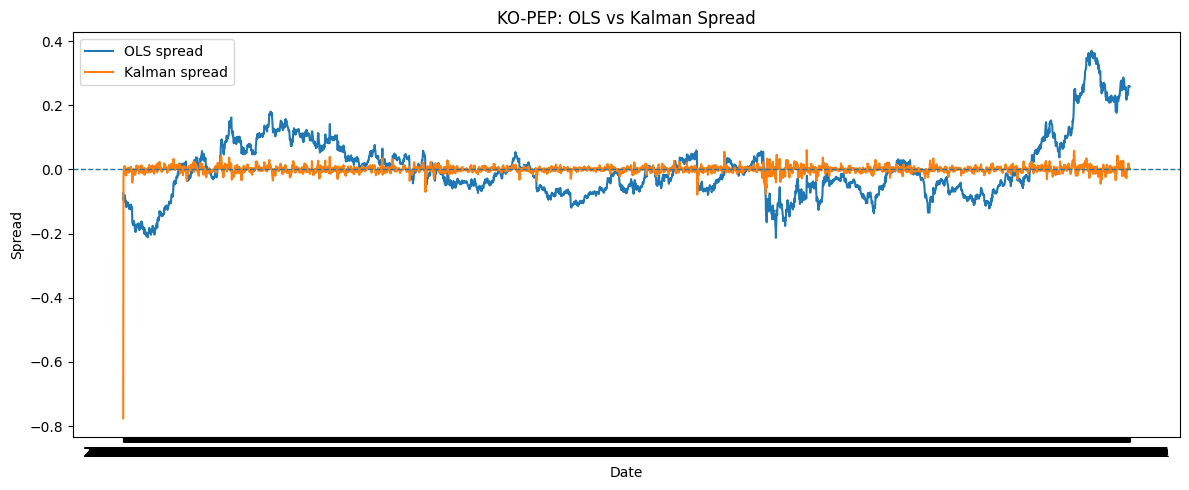

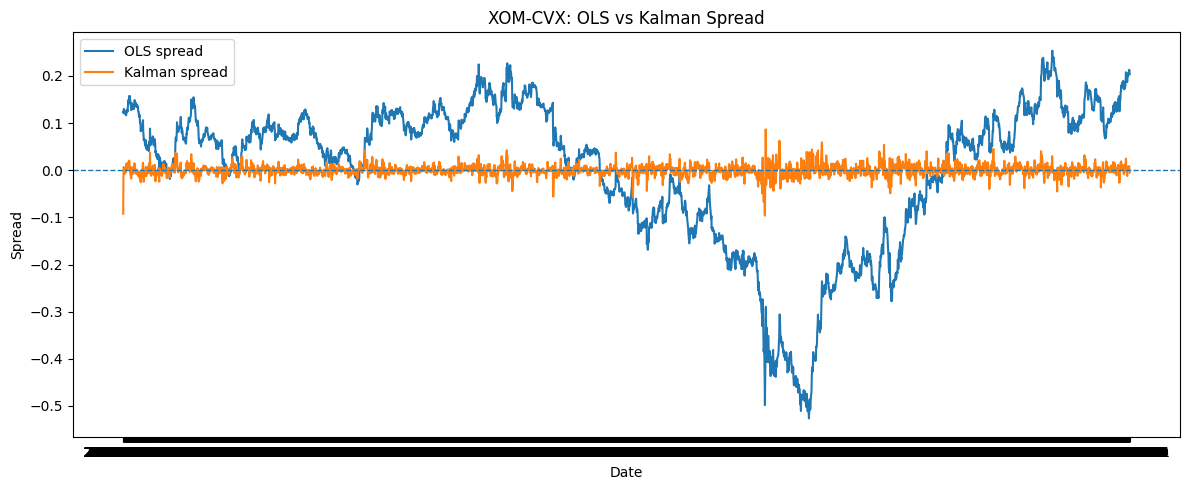

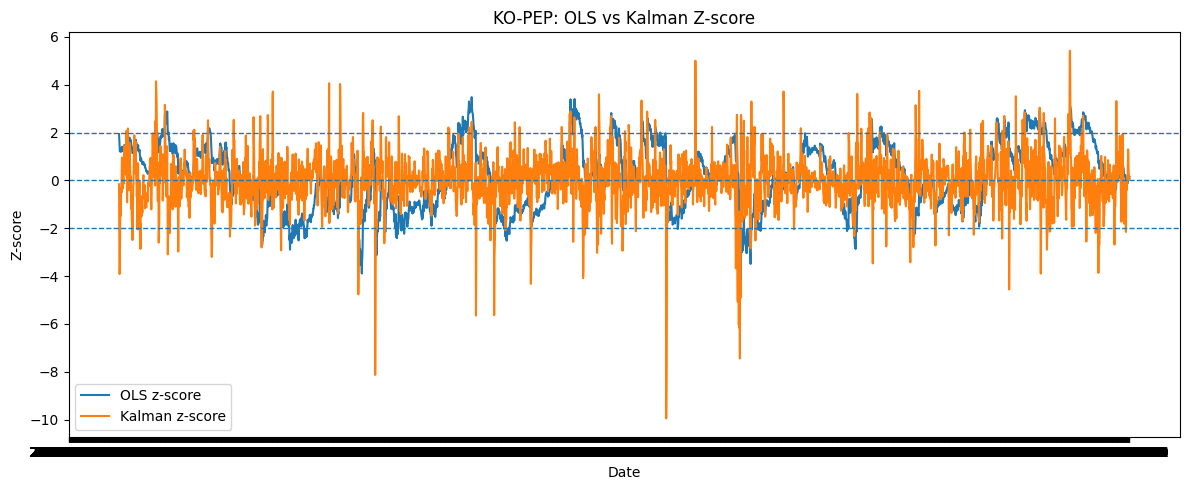

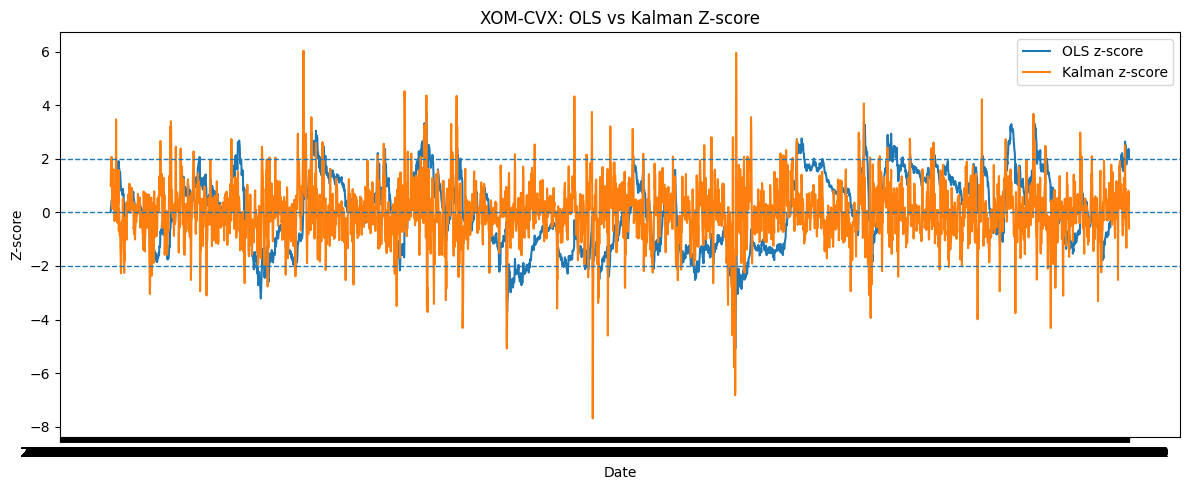

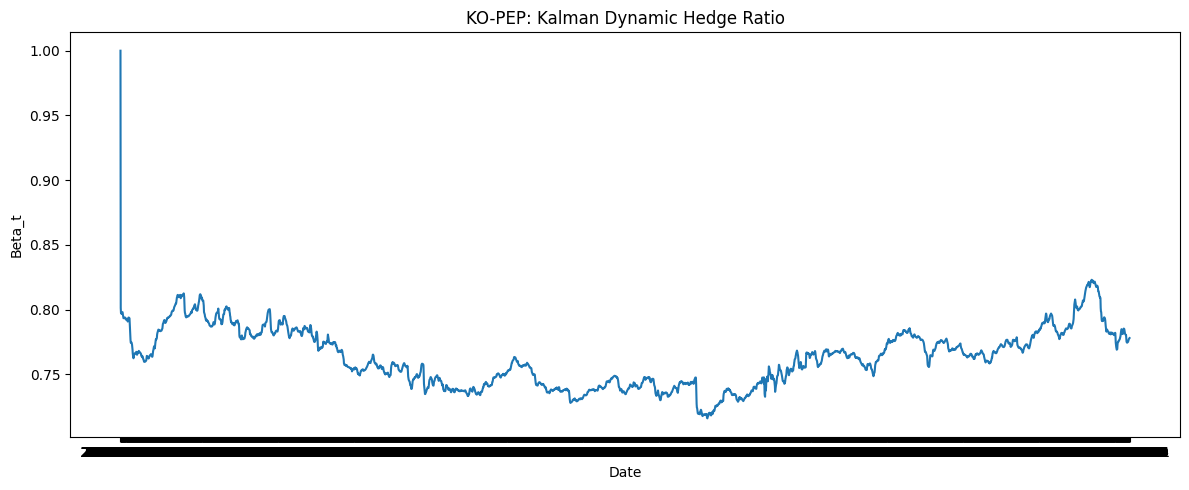

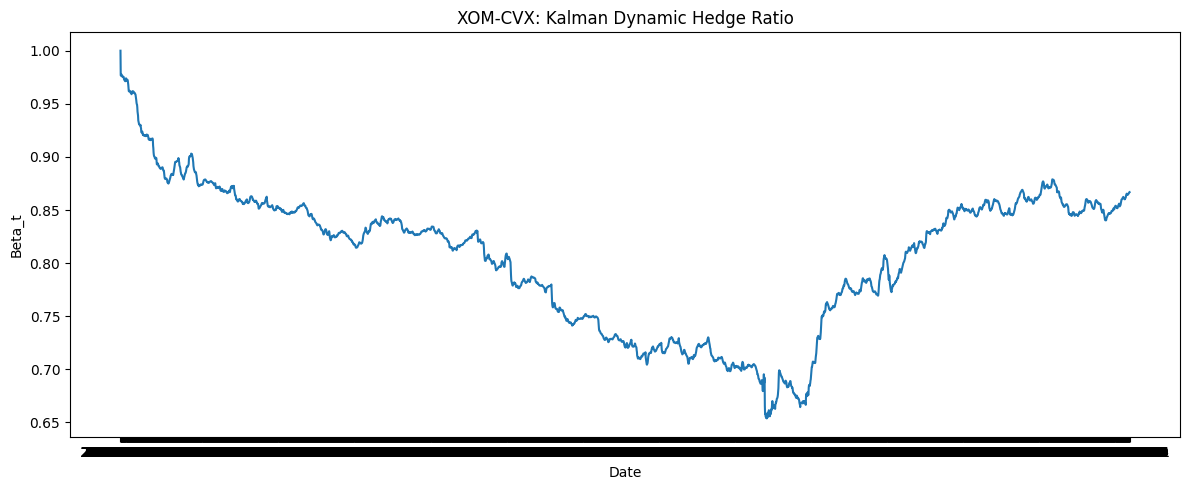

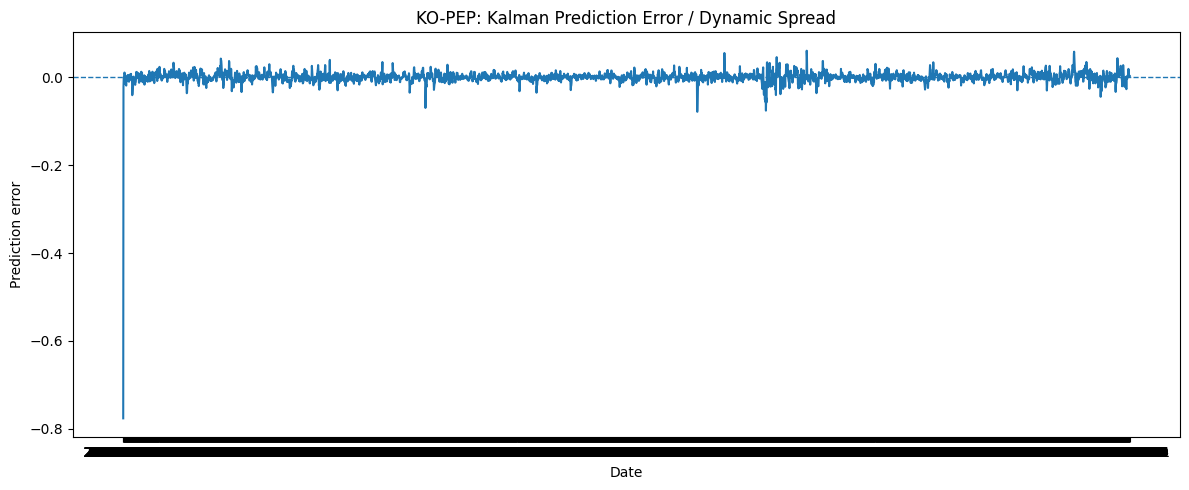

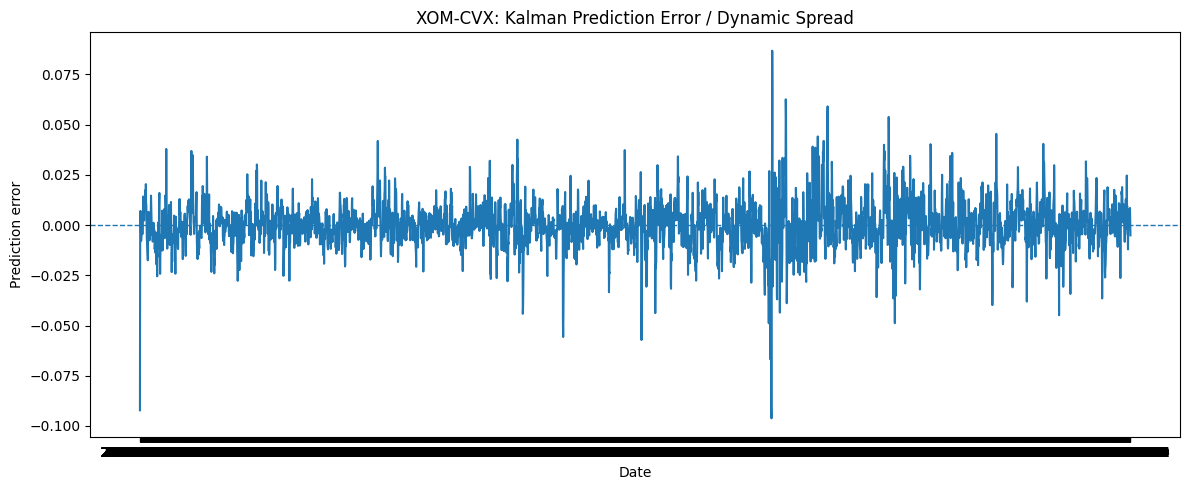

In [26]:
plot_spread(
    "KO-PEP",
    spread_ols_ko_pep,
    spread_kf_ko_pep
)

plot_spread(
    "XOM-CVX",
    spread_ols_xom_cvx,
    spread_kf_xom_cvx
)

plot_zscore(
    "KO-PEP",
    zscore_ols_ko_pep,
    zscore_kf_ko_pep
)

plot_zscore(
    "XOM-CVX",
    zscore_ols_xom_cvx,
    zscore_kf_xom_cvx
)

plot_kalman_beta(
    "KO-PEP",
    beta_kf_ko_pep
)

plot_kalman_beta(
    "XOM-CVX",
    beta_kf_xom_cvx
)

plot_prediction_error(
    "KO-PEP",
    spread_kf_ko_pep
)

plot_prediction_error(
    "XOM-CVX",
    spread_kf_xom_cvx
)

# out of sample spread validation
Does spread remain stable in future regimes? (If we estimate OLS on the past, does it still work in the future?)

Train OLS beta on train period

Apply fixed beta to validation/test periods

Compute spread stability metrics

Save table + plots

In [27]:
from statsmodels.tsa.stattools import adfuller

OUTPUT_DIR = DATA_DIR + "/validation_outputs/oos_validation_outputs"
FIG_DIR = OUTPUT_DIR + "/figures"


In [28]:
def adf_stat_pvalue(series):
    s = series.dropna()
    if len(s) < 30:
        return np.nan, np.nan
    result = adfuller(s)
    return result[0], result[1]


def spread_metrics(pair, model, period, spread):
    adf_stat, adf_p = adf_stat_pvalue(spread)

    return {
        "pair": pair,
        "model": model,
        "period": period,
        "spread_mean": spread.mean(),
        "spread_std": spread.std(),
        "spread_iqr": spread.quantile(0.75) - spread.quantile(0.25),
        "half_life": series_half_life(spread),
        "ADF_stat": adf_stat,
        "ADF_pvalue": adf_p,
        "n_obs": spread.dropna().shape[0]
    }

In [29]:
# OLS OOS
def fit_static_ols(y_train, x_train):
    X = np.column_stack([np.ones(len(x_train)), x_train.values])
    Y = y_train.values
    alpha, beta = np.linalg.lstsq(X, Y, rcond=None)[0]
    return alpha, beta


def static_ols_oos_validation(
    pair,
    y,
    x,
    train_start="2010-01-01",
    train_end="2020-12-31",
    val_start="2021-01-01",
    val_end="2023-12-31",
    test_start="2024-01-01",
    test_end="2025-12-31"
):
    y = y.copy()
    x = x.copy()
    y.index = pd.to_datetime(y.index)
    x.index = pd.to_datetime(x.index)

    y_train, x_train = y.loc[train_start:train_end], x.loc[train_start:train_end]
    y_val, x_val = y.loc[val_start:val_end], x.loc[val_start:val_end]
    y_test, x_test = y.loc[test_start:test_end], x.loc[test_start:test_end]

    alpha, beta = fit_static_ols(y_train, x_train)

    spread_train = y_train - (alpha + beta * x_train)
    spread_val = y_val - (alpha + beta * x_val)
    spread_test = y_test - (alpha + beta * x_test)

    table = pd.DataFrame([
        spread_metrics(pair, "Static OLS", "train", spread_train),
        spread_metrics(pair, "Static OLS", "validation", spread_val),
        spread_metrics(pair, "Static OLS", "test", spread_test)
    ])

    table["OLS_alpha_train"] = alpha
    table["OLS_beta_train"] = beta

    return table, spread_train, spread_val, spread_test

In [30]:
ols_ko, ols_ko_train, ols_ko_val, ols_ko_test = static_ols_oos_validation(
    "KO-PEP",
    KO_log_prices["KO"],
    PEP_log_prices["PEP"]
)

ols_xom, ols_xom_train, ols_xom_val, ols_xom_test = static_ols_oos_validation(
    "XOM-CVX",
    XOM_log_prices["XOM"],
    CVX_log_prices["CVX"]
)

In [31]:
#kalman OOS

# def kalman_one_step_spread(y, x, q=1e-4, r=1e-2):
#     alpha = pd.Series(index=y.index, dtype=float)
#     beta = pd.Series(index=y.index, dtype=float)
#     spread = pd.Series(index=y.index, dtype=float)

#     state_mean = np.array([0.0, 1.0])
#     state_cov = np.eye(2)

#     for i in range(len(y)):
#         obs_matrix = np.array([[1.0, x.iloc[i]]])

#         # one-step prediction before observing today's y
#         state_mean_pred = state_mean
#         state_cov_pred = state_cov + q * np.eye(2)

#         alpha.iloc[i] = state_mean_pred[0]
#         beta.iloc[i] = state_mean_pred[1]
#         spread.iloc[i] = y.iloc[i] - (alpha.iloc[i] + beta.iloc[i] * x.iloc[i])

#         # update after observing today's y
#         y_pred = (obs_matrix @ state_mean_pred).item()
#         innovation = y.iloc[i] - y_pred
#         S = (obs_matrix @ state_cov_pred @ obs_matrix.T).item() + r
#         K = state_cov_pred @ obs_matrix.T / S

#         state_mean = state_mean_pred + K.flatten() * innovation
#         state_cov = state_cov_pred - K @ obs_matrix @ state_cov_pred

#     return spread, alpha, beta


def kalman_oos_validation_from_existing(
    pair,
    spread_kf,
    beta_kf,
    alpha_kf,
    train_start="2010-01-01",
    train_end="2020-12-31",
    val_start="2021-01-01",
    val_end="2023-12-31",
    test_start="2024-01-01",
    test_end="2025-12-31"
):
    spread_kf.index = pd.to_datetime(spread_kf.index)
    beta_kf.index = pd.to_datetime(beta_kf.index)
    alpha_kf.index = pd.to_datetime(alpha_kf.index)

    spread_train = spread_kf.loc[train_start:train_end]
    spread_val = spread_kf.loc[val_start:val_end]
    spread_test = spread_kf.loc[test_start:test_end]

    table = pd.DataFrame([
        spread_metrics(pair, "Kalman", "train", spread_train),
        spread_metrics(pair, "Kalman", "validation", spread_val),
        spread_metrics(pair, "Kalman", "test", spread_test)
    ])

    table["Kalman_alpha_mean"] = alpha_kf.mean()
    table["Kalman_beta_mean"] = beta_kf.mean()
    table["Kalman_beta_std"] = beta_kf.std()
    table["Kalman_beta_min"] = beta_kf.min()
    table["Kalman_beta_max"] = beta_kf.max()

    return table, spread_train, spread_val, spread_test

In [32]:
kf_ko_oos, kf_ko_train, kf_ko_val, kf_ko_test = kalman_oos_validation_from_existing(
    "KO-PEP",
    spread_kf_ko_pep,
    beta_kf_ko_pep,
    alpha_kf_ko_pep
)

kf_xom_oos, kf_xom_train, kf_xom_val, kf_xom_test = kalman_oos_validation_from_existing(
    "XOM-CVX",
    spread_kf_xom_cvx,
    beta_kf_xom_cvx,
    alpha_kf_xom_cvx
)

In [33]:
oos_validation_table = pd.concat(
    [ols_ko, ols_xom, kf_ko_oos, kf_xom_oos],
    axis=0,
    ignore_index=True
)

oos_validation_table.to_csv(
    OUTPUT_DIR  + "/oos_spread_validation_table.csv",
    index=False
)

oos_validation_table

,pair,model,period,spread_mean,spread_std,spread_iqr,half_life,ADF_stat,ADF_pvalue,n_obs,OLS_alpha_train,OLS_beta_train,Kalman_alpha_mean,Kalman_beta_mean,Kalman_beta_std,Kalman_beta_min,Kalman_beta_max
0,KO-PEP,Static OLS,train,4.888349e-16,0.071660,0.085571,107.369843,-2.938345,4.106723e-02,2769,0.303312,0.729728,NaN,NaN,NaN,NaN,NaN
1,KO-PEP,Static OLS,validation,1.014776e-02,0.036782,0.045236,45.718551,-3.141238,2.364810e-02,753,0.303312,0.729728,NaN,NaN,NaN,NaN,NaN
2,KO-PEP,Static OLS,test,2.068712e-01,0.119092,0.185594,166.476066,-1.294373,6.317427e-01,502,0.303312,0.729728,NaN,NaN,NaN,NaN,NaN
3,XOM-CVX,Static OLS,train,-1.021293e-15,0.146797,0.131724,1589.225520,-0.219375,9.361724e-01,2769,1.467369,0.579661,NaN,NaN,NaN,NaN,NaN
4,XOM-CVX,Static OLS,validation,5.124329e-02,0.182901,0.356401,129.922367,-2.115786,2.382146e-01,753,1.467369,0.579661,NaN,NaN,NaN,NaN,NaN
5,XOM-CVX,Static OLS,test,3.307154e-01,0.046219,0.057299,38.445245,-2.202447,2.053585e-01,502,1.467369,0.579661,NaN,NaN,NaN,NaN,NaN
6,KO-PEP,Kalman,train,-1.851299e-04,0.017959,0.009865,0.893951,-14.495635,6.047566e-27,2769,NaN,NaN,0.184089,0.763005,0.022442,0.716011,1.0
7,KO-PEP,Kalman,validation,-3.825272e-06,0.008092,0.009102,1.794775,-8.190009,7.713241e-13,753,NaN,NaN,0.184089,0.763005,0.022442,0.716011,1.0
8,KO-PEP,Kalman,test,1.542969e-03,0.011686,0.013492,1.975342,-10.304201,3.311529e-18,502,NaN,NaN,0.184089,0.763005,0.022442,0.716011,1.0
9,XOM-CVX,Kalman,train,-5.816017e-04,0.011066,0.010852,1.779404,-13.773788,9.573733e-26,2769,NaN,NaN,0.524640,0.805750,0.065989,0.653816,1.0


In [34]:
def plot_oos_spread_comparison(
    pair,
    ols_train,
    ols_val,
    ols_test,
    kf_train,
    kf_val,
    kf_test,
    train_end="2020-12-31",
    val_end="2023-12-31"
):
    ols_spread = pd.concat([ols_train, ols_val, ols_test])
    kf_spread = pd.concat([kf_train, kf_val, kf_test])

    plt.figure(figsize=(12, 5))

    plt.plot(ols_spread.index, ols_spread, label="Static OLS spread")
    plt.plot(kf_spread.index, kf_spread, label="Kalman spread")

    plt.axhline(0, linestyle="--", linewidth=1)

    # split lines
    plt.axvline(pd.to_datetime(train_end), linestyle="--", linewidth=1, color="red",label="Train/Val split")
    plt.axvline(pd.to_datetime(val_end), linestyle="--", linewidth=1, color = "green", label="Val/Test split")

    plt.title(f"{pair}: OOS Spread Validation")
    plt.xlabel("Date")
    plt.ylabel("Spread")
    plt.legend()
    plt.tight_layout()

    plt.savefig(FIG_DIR + f"/{pair}_oos_spread_validation.png", dpi=300)
    plt.show()

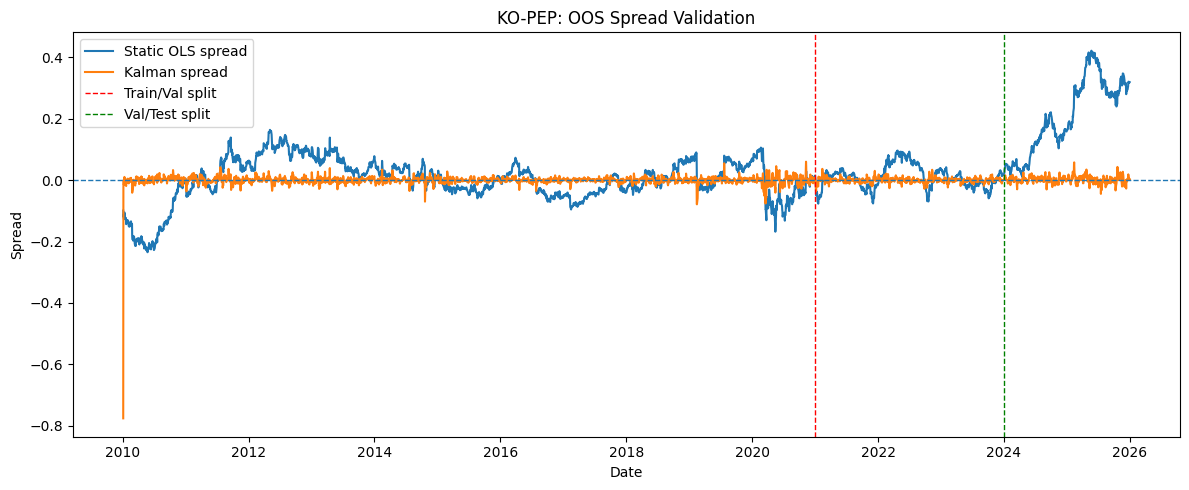

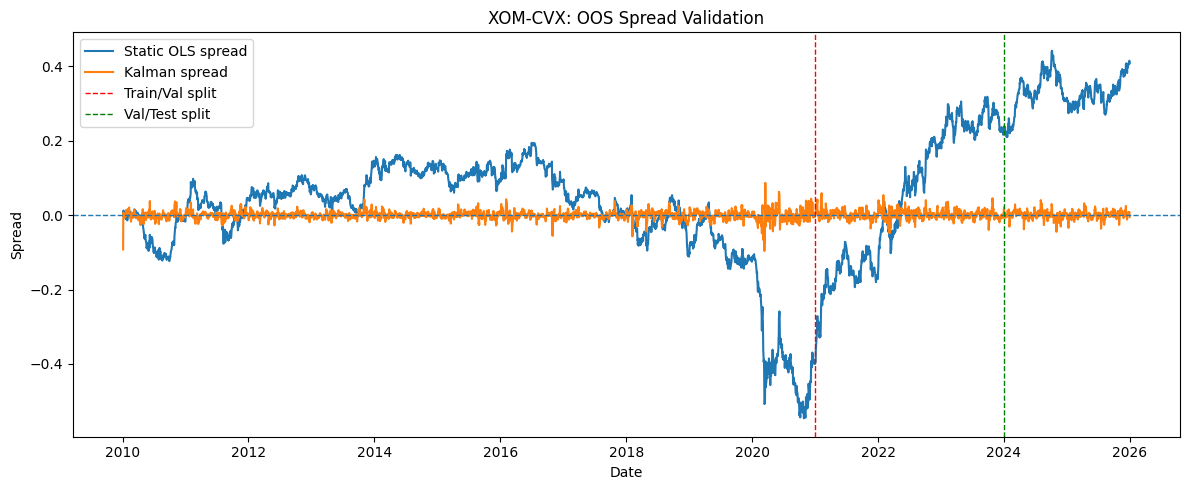

In [35]:
plot_oos_spread_comparison(
    "KO-PEP",
    ols_ko_train,
    ols_ko_val,
    ols_ko_test,
    kf_ko_train,
    kf_ko_val,
    kf_ko_test,
    train_end="2020-12-31",
    val_end="2023-12-31"
)

plot_oos_spread_comparison(
    "XOM-CVX",
    ols_xom_train,
    ols_xom_val,
    ols_xom_test,
    kf_xom_train,
    kf_xom_val,
    kf_xom_test,
    train_end="2020-12-31",
    val_end="2023-12-31"
)

In [36]:
OUTPUT_DIR = DATA_DIR + "/output"
backtest_input.to_csv(OUTPUT_DIR + "/backtest_input_with_kalman.csv", index=False)


# 